3rd Test - Walker segmentation - Image 000 - 512x512


In [367]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from numpy import ndarray


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)



In [368]:
# Check input shape
print(hsv_img.shape) # Result: (1080, 1920, 3)

(1080, 1920, 3)


In [369]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
3rd Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [142, 148, 187]
upper_bound = [145, 178, 225]

4th Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [138, 150, 165]
upper_bound = [148, 160, 225]
"""

'\n3rd Test:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [142, 148, 187]\nupper_bound = [145, 178, 225]\n\n4th Test:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [138, 150, 165]\nupper_bound = [148, 160, 225]\n'

In [370]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [371]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

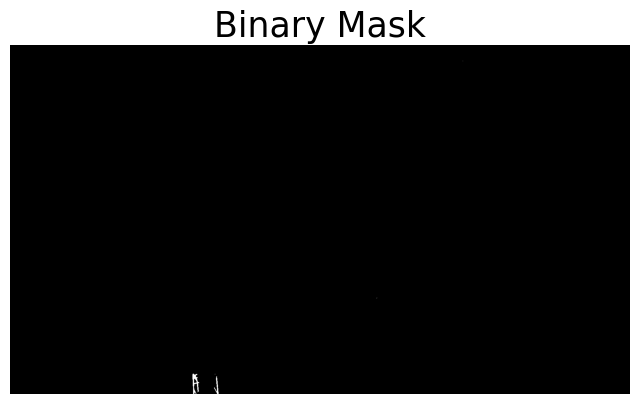

In [ ]:
### Process ###
# First Step - Limits
# 1 - Define Walker color limits >> HSV (H:142, S:150, V:187) to (H:145, S:177, V:225)
# New values ​​considering preprocessing
lower_bound = np.array([142, 150, 187]) # Hue, Saturation, Value
upper_bound = np.array([145, 177, 225]) # Hue, Saturation, Value

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [374]:
# 2.3 - Check Mask Values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Values are 0 and 255.
"""

'\nValues are 0 and 255.\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

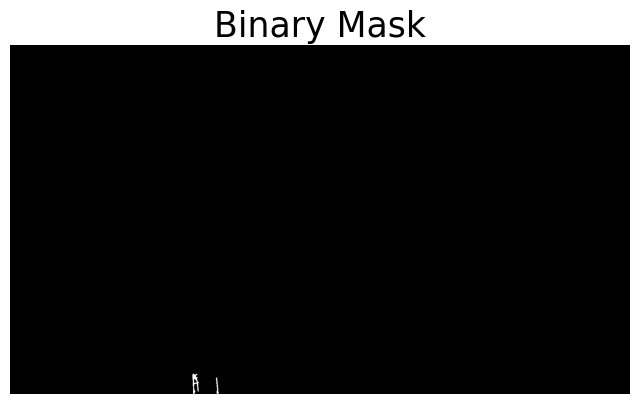

In [375]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

'\nResult: Terrible. Removes noise, but in complex objects the gaps in the object are filled\nUpdate: After refactor the code now it is possible filter the noise with complex objects\n\nConsider process and min_area as a factor to refactor the image_manipulation.py\n'

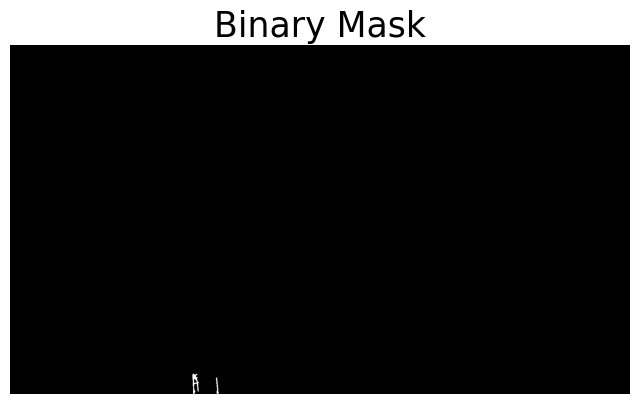

In [376]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 10

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result (cv.RETR_EXTERNAL): Terrible. Removes noise, but in complex objects the gaps in the object are filled
Update (cv.RETR_TREE): After refactor the code now it is possible filter the noise with complex objects

Consider process and min_area as a factor to refactor the image_manipulation.py
"""

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

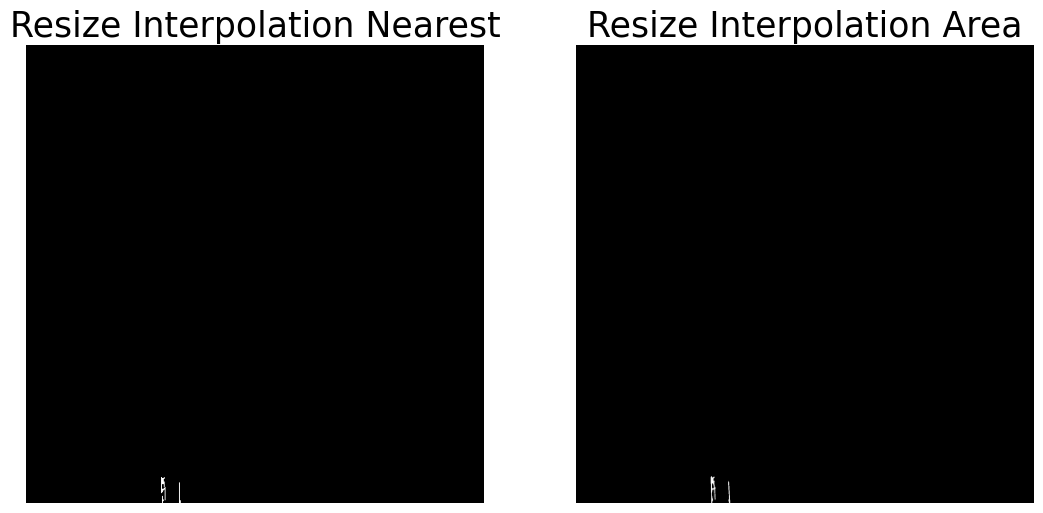

In [377]:
# Test: Resize mask and image
mask1 = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)
mask2 = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA) # chosen

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask1, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

In [379]:
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Image", mask)

# cv.imshow("Inspect Image", mask1) # Mask 1 (512x512 - Nearest): Values are 0 and 255
cv.imshow("Inspect Image", mask2)   # Mask 2 (512x512 - Area): Values between 0 and 255

cv.waitKey(0)
cv.destroyAllWindows()

"""
Results: 
1) Nearest Interpolation lost the shape of the object
2) Area interpolation maintained the shape of the object, however the object is in grayscale.
"""

'\nResults: \n1) Nearest Interpolation lost the shape of the object\n2) Area interpolation maintained the shape of the object, however the object is in grayscale.\n'

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

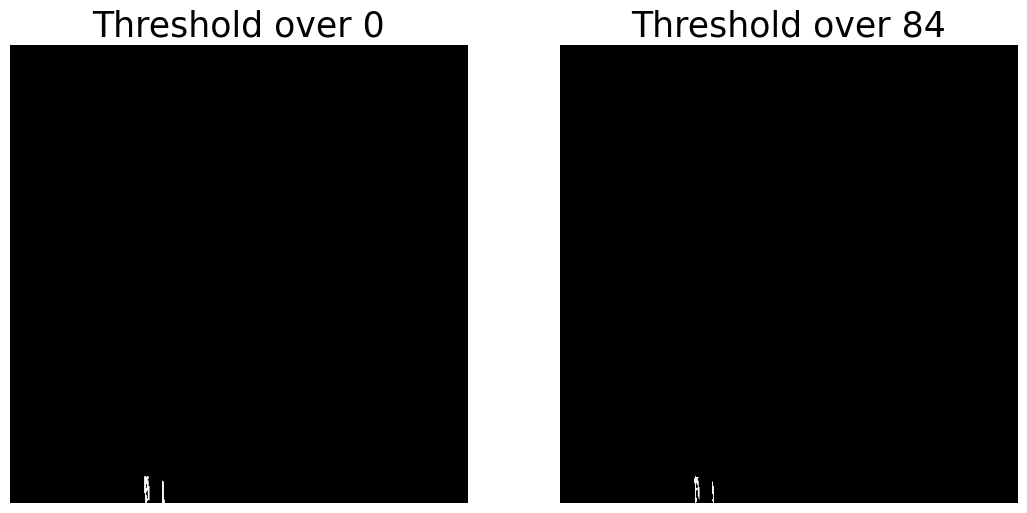

In [381]:
# 2.3 - Binarize mask
mask2a = np.where(mask2 > 0, 255, 0).astype(np.uint8) # chosen
mask2b = np.where(mask2 > 84, 255, 0).astype(np.uint8)

# 2.4 - Visualize binary mask
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask2a, cmap='gray')
plt.title("Threshold over 0",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2b, cmap='gray')
plt.title("Threshold over 84",fontdict={'fontsize': 25})
plt.axis('off')



In [383]:
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Image", mask)

cv.imshow("Inspect Image", mask2a) # Mask 2 with TH > 0
# cv.imshow("Inspect Image", mask2b)   # Mask 2 with TH > 106

cv.waitKey(0)
cv.destroyAllWindows()

"""
Results: 
mask2a - This is the acceptable binarization, the complex object becomes less detailed and more bulky
mask2b - This is the adjusted binarization, the complex object becomes more detailed and less bulky
"""

'\nResults: \nmask2a - This is the acceptable binarization, the complex object becomes less detailed and more bulky\nmask2b - This is the adjusted binarization, the complex object becomes more detailed and less bulky\n'

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

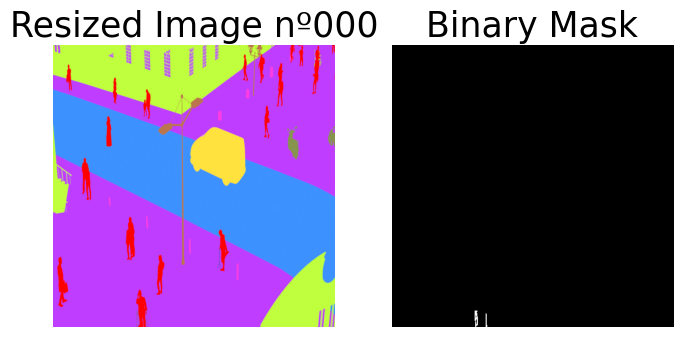

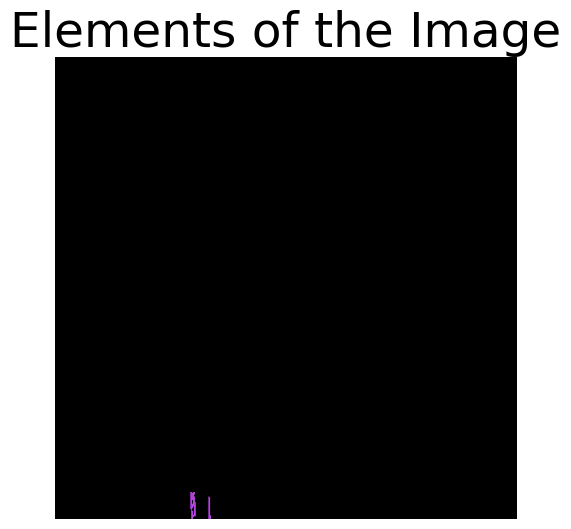

In [384]:
# Visualize Segmentation
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)

# Setup Plot
plt.figure(figsize=[8,8])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2a, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask2a)

# Plotting result
plt.figure(figsize=[6,6])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

4th Test - Walker Segmentation - Image 368 - 512x512 (WIP)

In [385]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [386]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

In [387]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [388]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
3rd Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [142, 148, 187]
upper_bound = [145, 178, 225]

4th Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [138, 150, 165]
upper_bound = [148, 160, 197]
"""

'\n3rd Test:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [142, 148, 187]\nupper_bound = [145, 178, 225]\n\n4th Test:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [138, 150, 165]\nupper_bound = [148, 160, 197]\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

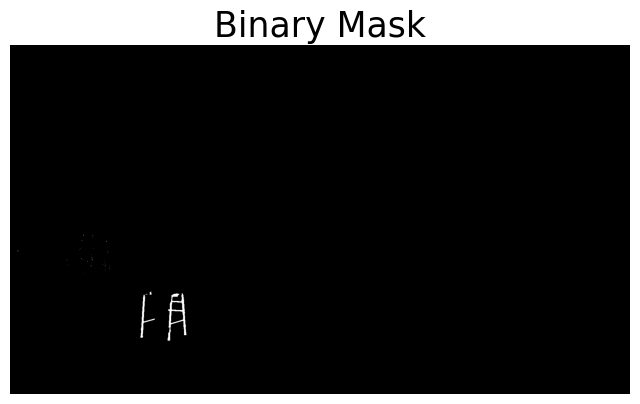

In [ ]:
### Process ###
# First Step - Limits
# 1 - Define Walker color limits >> HSV (H:142, S:150, V:187) to (H:145, S:177, V:225)
# New values ​​considering preprocessing
lower_bound = np.array([142, 150, 187]) # Hue, Saturation, Value
upper_bound = np.array([145, 177, 225]) # Hue, Saturation, Value

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

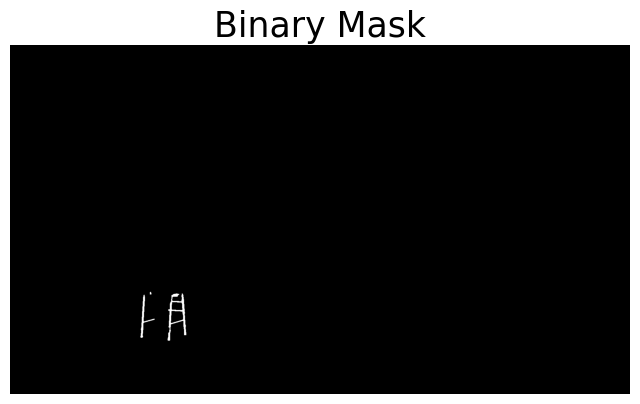

In [390]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

'\nResult: Terrible. Removes noise, but in complex objects the gaps in the object are filled\nUpdate: After refactor the code now it is possible filter the noise with complex objects\n\nConsider process and min_area as a factor to refactor the image_manipulation.py\n'

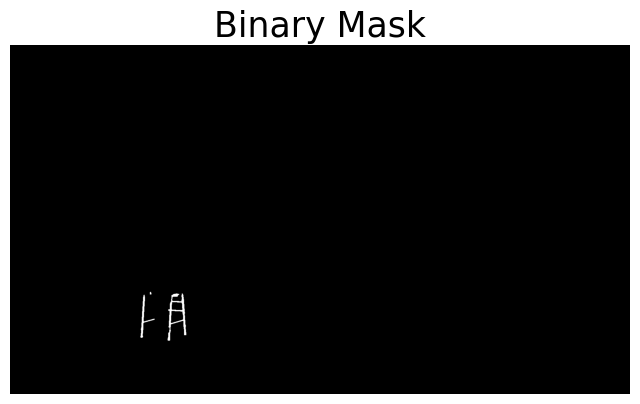

In [391]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 10

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result (cv.RETR_EXTERNAL): Terrible. Removes noise, but in complex objects the gaps in the object are filled
Update (cv.RETR_TREE): After refactor the code now it is possible filter the noise with complex objects

Consider process and min_area as a factor to refactor the image_manipulation.py
"""

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

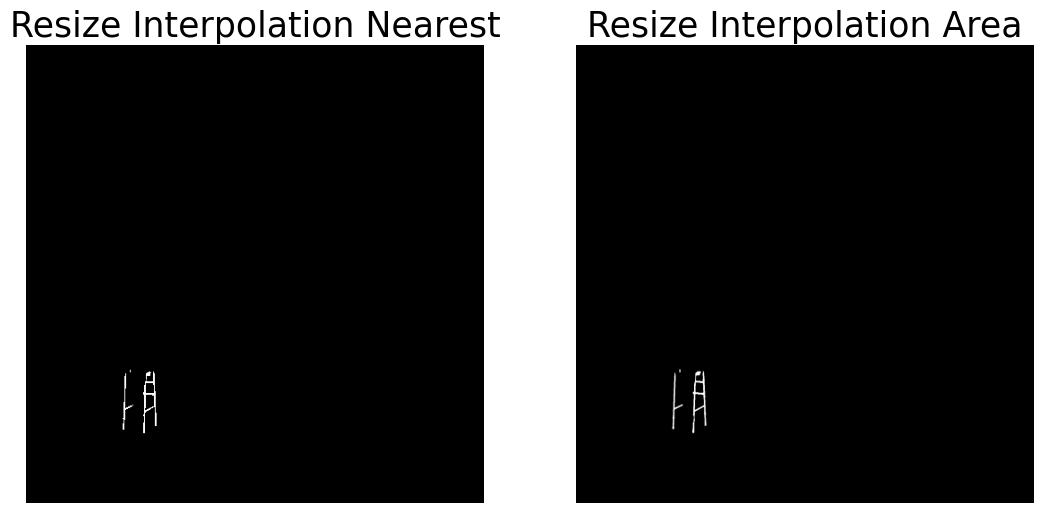

In [392]:
# Test: Resize mask and image
mask1 = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)
mask2 = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask1, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

In [393]:
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Image", mask)

# cv.imshow("Inspect Image", mask1) # Mask 1 (512x512 - Nearest): Values are 0 and 255
cv.imshow("Inspect Image", mask2)   # Mask 2 (512x512 - Area): Values between 0 and 255

cv.waitKey(0)
cv.destroyAllWindows()


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

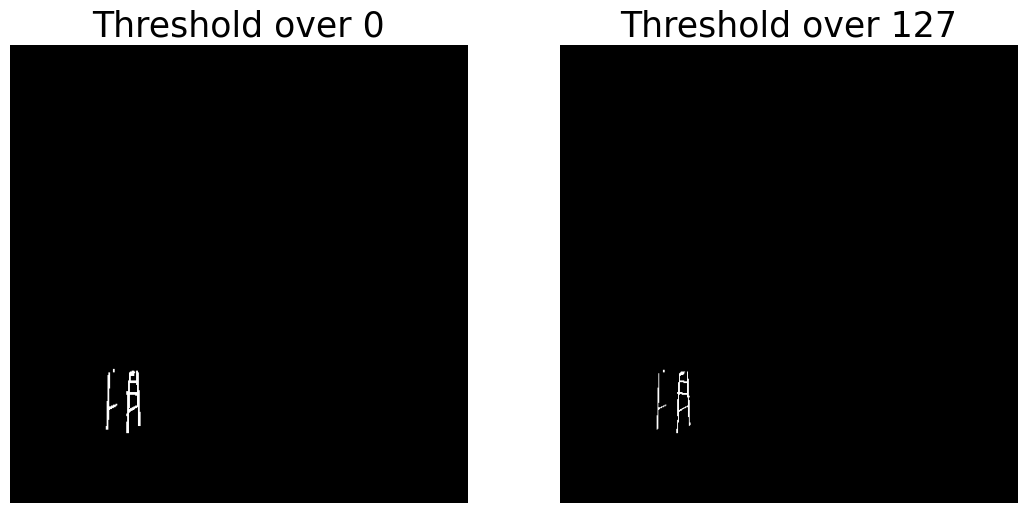

In [394]:
# 2.2 - Binarize
th0 = np.where(mask2 > 0, 255, 0).astype(np.uint8) # chosen
th127 = np.where(mask2 > 127, 255, 0).astype(np.uint8)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(th0, cmap='gray')
plt.title("Threshold over 0",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(th127, cmap='gray')
plt.title("Threshold over 127",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
cv.imshow("Inspect Image", th0) # chosen
# cv.imshow("Inspect Image", th127)

cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

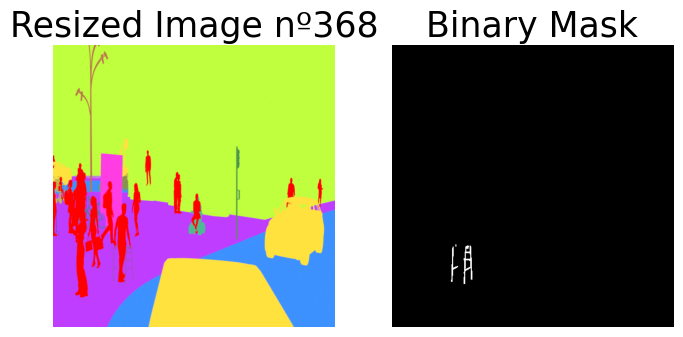

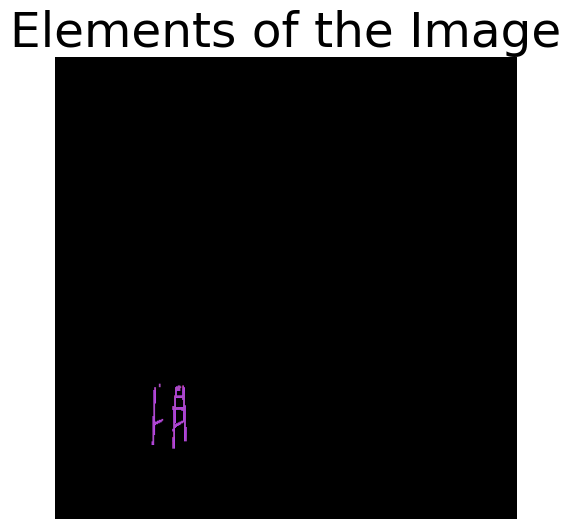

In [395]:
# Visualize Segmentation
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
mask = th0

# Setup Plot
plt.figure(figsize=[8,8])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)


# Plotting result
plt.figure(figsize=[6,6])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')